# Quantum Hardware Characterization and Region Recommendation

## Background

Modern quantum hardware is not perfectly uniform. Different regions of a device exhibit different operational characteristics due to calibration, reliability, connectivity, and other factors.

This project analyzes a calibration snapshot and the coupling topology of the IBM Kingston device to identify the best-performing connected regions of qubits.

## Data

- `ibm_kingston_calibrations_2026-03-31T09_24_11Z.csv` — per-qubit and per-edge calibration snapshot
- `ibm_kingston_topology_complete.json` — device topology and coupling map

## Contents

1. Dataset analysis
2. Hardware representation
3. Methodology for region selection
4. Recommended 16-qubit region
5. Recommended 32-qubit region
6. Recommendation rationale and limitations

## Tools Used

- Python
- NumPy
- Pandas
- NetworkX
- Matplotlib

In [1]:
import json
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.axisbelow': True})
RNG_SEED = 7

In [2]:
CALIBRATION_FILE = r"ibm_kingston_calibrations_2026-03-31T09_24_11Z.csv"
TOPOLOGY_FILE = r"ibm_kingston_topology_complete.json"

df = pd.read_csv(CALIBRATION_FILE)

with open(TOPOLOGY_FILE) as f:
    topology = json.load(f)

print(df.shape)
df.head(10)

(156, 19)


,Qubit,T1 (us),T2 (us),Readout assignment error,Prob meas0 prep1,Prob meas1 prep0,Readout length (ns),ID error,Single-qubit gate length (ns),RX error,Z-axis rotation (rz) error,√x (sx) error,Pauli-X error,CZ error,Gate length (ns),RZZ error,MEASURE error,MEASURE_2 error,Operational
0,0,290.800821,298.140732,0.011475,0.014404,0.008545,2280,0.000205,32,0.000205,0,0.000205,0.000205,1:0.0010167457696165227,1:68,1:0.0010602119472144789,0.011475,0.016602,Yes
1,1,372.822654,437.021834,0.164795,0.100342,0.229248,2280,0.000181,32,0.000181,0,0.000181,0.000181,2:0.0009609959626648845;0:0.0010167457696165227,2:68;0:68,2:0.0009016463575797495;0:0.0010602119472144789,0.164795,0.081055,Yes
2,2,305.112602,107.784842,0.008057,0.010742,0.005371,2280,0.000100,32,0.000100,0,0.000100,0.000100,1:0.0009609959626648845;3:0.0012523142615088745,1:68;3:68,1:0.0009016463575797495;3:0.000930022916350165,0.008057,0.008057,Yes
3,3,354.894616,483.530444,0.008301,0.011475,0.005127,2280,0.000243,32,0.000243,0,0.000243,0.000243,16:0.0012413347520312812;2:0.00125231426150887...,16:68;2:68;4:68,16:0.001184823243668115;2:0.000930022916350165...,0.008301,0.007324,Yes
4,4,316.778855,53.238112,0.022339,0.018799,0.025879,2280,0.000282,32,0.000282,0,0.000282,0.000282,3:0.002007963045889627;5:0.002521856056860644,3:68;5:68,3:0.0018174791538967394;5:0.0026275206583171173,0.022339,0.013916,Yes
5,5,133.141405,61.718647,0.006836,0.009521,0.004150,2280,0.000336,32,0.000336,0,0.000336,0.000336,6:0.002482708269532563;4:0.002521856056860644,6:68;4:68,6:0.002667745536042654;4:0.0026275206583171173,0.006836,0.008545,Yes
6,6,262.445610,123.580780,0.010498,0.010010,0.010986,2280,0.000225,32,0.000225,0,0.000225,0.000225,5:0.002482708269532563;7:0.007143246937313497,5:68;7:80,5:0.002667745536042654;7:0.010732557806185289,0.010498,0.015869,Yes
7,7,383.084498,77.176985,0.021362,0.021484,0.021240,2280,0.000291,32,0.000291,0,0.000291,0.000291,17:0.005846746467566055;6:0.007143246937313497...,17:68;6:80;8:68,17:0.004331245341646528;6:0.010732557806185289...,0.021362,0.016846,Yes
8,8,288.398879,84.167358,0.005737,0.010010,0.001465,2280,0.000283,32,0.000283,0,0.000283,0.000283,9:0.0023246380453462445;7:0.007194008488652814,9:68;7:68,9:0.0019170841750110468;7:0.0042280283951493525,0.005737,0.004883,Yes
9,9,128.251925,35.647702,0.005859,0.008057,0.003662,2280,0.000547,32,0.000547,0,0.000547,0.000547,8:0.0023246380453462445;10:0.004617037541619767,8:68;10:68,8:0.0019170841750110468;10:0.005229698133982857,0.005859,0.007568,Yes


# 1. Initial Dataset Analysis

A first look at the calibration snapshot: column types, missing values, redundant columns, distributions, and defective qubits.

In [3]:
# Printing the columns and their data types, 
print('Columns and Data Types')
print(df.dtypes.to_string())

Columns and Data Types
Qubit                              int64
T1 (us)                          float64
T2 (us)                          float64
Readout assignment error         float64
Prob meas0 prep1                 float64
Prob meas1 prep0                 float64
Readout length (ns)                int64
ID error                         float64
Single-qubit gate length (ns)      int64
RX error                         float64
Z-axis rotation (rz) error         int64
√x (sx) error                    float64
Pauli-X error                    float64
CZ error                          object
Gate length (ns)                  object
RZZ error                         object
MEASURE error                    float64
MEASURE_2 error                  float64
Operational                       object


In [4]:
print('Missing values per column (only columns with gaps shown)')
miss = df.isna().sum()
print(miss[miss > 0].to_string())

print('\n"Operational" flag')
print(df['Operational'].value_counts().to_string())

Missing values per column (only columns with gaps shown)
T1 (us)          1
T2 (us)          1
ID error         3
RX error         3
√x (sx) error    3
Pauli-X error    3
CZ error         3
RZZ error        4

"Operational" flag
Operational
Yes    156


In [5]:
print('\nRedundancy checks (whether all the values in these columns are identical)')
onq = ['ID error', 'RX error', '\u221ax (sx) error', 'Pauli-X error']
same = df[onq].dropna().nunique(axis=1).eq(1).all()
print(f'\nID / RX / SX / X error columns are all identical : {same}')

# Check whether the Z-axis rotation error is identically zero
z_axis_zero = bool((df["Z-axis rotation (rz) error"] == 0).all())
print(f'Z-axis rotation (rz) error identically zero: {z_axis_zero}')

# Check whether the "MEASURE error" duplicates the "Readout assignment error"
measure_duplicates_readout = bool(np.allclose(df["MEASURE error"], df["Readout assignment error"]))
print(f'"MEASURE error" duplicates "Readout assignment error" : {measure_duplicates_readout}')

readout_length_constant = df["Readout length (ns)"].nunique() == 1
print(f'Readout length constant: {readout_length_constant}', f'({df["Readout length (ns)"].iloc[0]} ns)')

one_q_gate_length_constant = df["Single-qubit gate length (ns)"].nunique() == 1
print(f'1Q gate length constant: {one_q_gate_length_constant}',f'({df["Single-qubit gate length (ns)"].iloc[0]} ns)')



Redundancy checks (whether all the values in these columns are identical)

ID / RX / SX / X error columns are all identical : True
Z-axis rotation (rz) error identically zero: True
"MEASURE error" duplicates "Readout assignment error" : True
Readout length constant: True (2280 ns)
1Q gate length constant: True (32 ns)


In [6]:
KEY = ['T1 (us)', 'T2 (us)', '\u221ax (sx) error', 'Readout assignment error',
       'Prob meas0 prep1', 'Prob meas1 prep0', 'CZ error', 'Gate length (ns)']
desc = df[KEY].describe(percentiles=[.05, .25, .5, .75, .95]).T
print(desc.round(5).to_string())


                          count       mean        std       min         5%        25%        50%        75%        95%        max
T1 (us)                   155.0  271.04730   81.32369  65.88747  126.94109  212.14275  280.24909  336.06639  384.91781  479.72981
T2 (us)                   155.0  171.80942  114.42383  11.92660   27.21381   81.20891  134.26065  242.31706  389.12134  488.48211
√x (sx) error             153.0    0.00030    0.00049   0.00009    0.00012    0.00017    0.00021    0.00030    0.00049    0.00584
Readout assignment error  156.0    0.02463    0.06004   0.00317    0.00415    0.00623    0.00928    0.01898    0.08591    0.50488
Prob meas0 prep1          156.0    0.02347    0.04911   0.00269    0.00507    0.00726    0.01050    0.01880    0.07959    0.49805
Prob meas1 prep0          156.0    0.02627    0.09205   0.00049    0.00146    0.00366    0.00769    0.01764    0.06909    0.98853


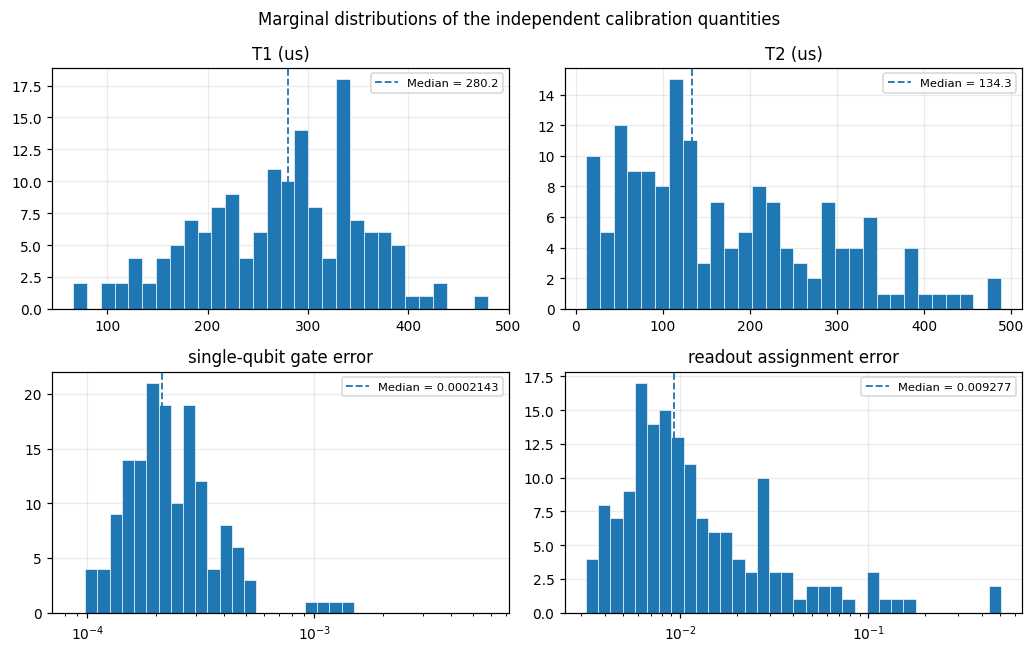

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 6))

plots = [
    ('T1 (us)', False, 'T1 (us)'),
    ('T2 (us)', False, 'T2 (us)'),
    ('√x (sx) error', True, 'single-qubit gate error'),
    ('Readout assignment error', True, 'readout assignment error')
]

for ax, (column, log_scale, title) in zip(axes.ravel(), plots):
    values = df[column].dropna()

    if log_scale:
        positive_values = values[values > 0]
        bins = np.logspace(
            np.log10(positive_values.min()),
            np.log10(values.max()),
            35
        )
    else:
        bins = 30

    ax.hist(
        values,
        bins=bins,
        edgecolor='white',
        linewidth=0.4
    )

    if log_scale:
        ax.set_xscale('log')

    median = values.median()

    ax.axvline(
        median,
        linestyle='--',
        linewidth=1.2,
        label=f'Median = {median:.4g}'
    )

    ax.set_title(title)
    ax.legend(fontsize=7.5)

fig.suptitle(
    'Marginal distributions of the independent calibration quantities'
)

fig.tight_layout()
plt.show()

In [8]:
defects = []

for _, r in df.iterrows():
    q = int(r['Qubit']); flags = []
    if not np.isfinite(r['T1 (us)']) or not np.isfinite(r['T2 (us)']):
        flags.append('no coherence data')
    if not np.isfinite(r['\u221ax (sx) error']):
        flags.append('no 1Q gate calibration')
    if r['Readout assignment error'] >= 0.40:
        flags.append(f"readout error {r['Readout assignment error']:.3f}")
    if flags:
        defects.append((q, '; '.join(flags), r['Operational']))

print('Qubits with defects')
print(pd.DataFrame(defects, columns=['qubit', 'problem', 'Operational flag']).to_string(index=False))

print('\n The two extreme readout qubits > 40% readout assignment error')
print(df.loc[df['Readout assignment error'] >= 0.40,
             ['Qubit', 'T1 (us)', 'T2 (us)', '\u221ax (sx) error',
              'Prob meas0 prep1', 'Prob meas1 prep0',
              'Readout assignment error']].round(5).to_string(index=False))

Qubits with defects
 qubit                                                        problem Operational flag
    96                                            readout error 0.496              Yes
   112                                         no 1Q gate calibration              Yes
   113                                         no 1Q gate calibration              Yes
   146 no coherence data; no 1Q gate calibration; readout error 0.505              Yes

 The two extreme readout qubits > 40% readout assignment error
 Qubit   T1 (us)   T2 (us)  √x (sx) error  Prob meas0 prep1  Prob meas1 prep0  Readout assignment error
    96 332.04882 155.75066        0.00018           0.00269           0.98853                   0.49561
   146       NaN       NaN            NaN           0.49805           0.51099                   0.50488


This suggests that Operational does not mean the qubits can be used in the region. 

In [9]:
# Topology summary supplied in the JSON
topology_summary = pd.Series(topology["summary"], name="value")
print("Topology summary:")
display(topology_summary.to_frame())

# Compare the JSON topology to the calibration edge data.
def parse_edge_field(value):
    if pd.isna(value):
        return {}
    parsed = {}
    for item in str(value).split(";"):
        if not item:
            continue
        neighbor, error = item.split(":")
        parsed[int(neighbor)] = float(error)
    return parsed

edge_samples = defaultdict(list)
for _, row in df.iterrows():
    q = int(row["Qubit"])
    for neighbor, error in parse_edge_field(row["CZ error"]).items():
        edge_samples[tuple(sorted((q, neighbor)))].append(error)

edge_cz = pd.Series({edge: np.mean(errors) for edge, errors in edge_samples.items()}, name="CZ error")
topology_edges = {tuple(edge) for edge in topology["coupling_map_undirected"]}
calibrated_edges = set(edge_cz.index)
missing_cz_edges = sorted(topology_edges - calibrated_edges)
extra_cz_edges = sorted(calibrated_edges - topology_edges)

print(f"Topology edges: {len(topology_edges)}")
print(f"Edges with CZ calibration: {len(calibrated_edges)}")
print(f"Topology edges without CZ calibration: {len(missing_cz_edges)}")
if missing_cz_edges:
    print("Missing calibrated edges:", missing_cz_edges)
assert not extra_cz_edges, f"Calibration contains edges not present in topology: {extra_cz_edges}"


Topology summary:


,value
num_directed_edges,352.00000
num_undirected_edges,176.00000
min_degree,1.00000
max_degree,3.00000
avg_degree,2.25641
num_connected_components,1.00000
largest_component_size,156.00000


Topology edges: 176
Edges with CZ calibration: 170
Topology edges without CZ calibration: 6
Missing calibrated edges: [(111, 112), (112, 113), (120, 121), (130, 131), (145, 146), (146, 147)]


In [10]:
cz_err, cz_len, rzz_err = {}, {}, {}
for _, r in df.iterrows():
    q = int(r['Qubit'])
    for n, v in parse_edge_field(r['CZ error']).items():
        cz_err[tuple(sorted((q, n)))] = v
    for n, v in parse_edge_field(r['Gate length (ns)']).items():
        cz_len[tuple(sorted((q, n)))] = v
    for n, v in parse_edge_field(r['RZZ error']).items():
        rzz_err[tuple(sorted((q, n)))] = v

edges_declared = [tuple(sorted(e)) for e in topology['coupling_map_undirected']]

print('device :', topology['device_name'], '/', topology['num_qubits'], 'qubits')
print('native gates :', topology['native_gates'])
print('declared undirected edges :', len(edges_declared))
print('edges with a CZ error:', len(cz_err))
print('edges with a gate length :', len(cz_len))
print('edges with an RZZ error:', len(rzz_err))

cz_vals = np.array(list(cz_err.values()))
print('\nCZ error   median %.2e   mean %.2e   max %.2e (%.0fx median)'
      % (np.median(cz_vals), cz_vals.mean(), cz_vals.max(), cz_vals.max() / np.median(cz_vals)))

device : ibm_kingston / 156 qubits
native gates : ['cz', 'id', 'rz', 'sx', 'x']
declared undirected edges : 176
edges with a CZ error: 170
edges with a gate length : 176
edges with an RZZ error: 167

CZ error   median 1.84e-03   mean 3.54e-03   max 6.03e-02 (33x median)


## Observations

1. So RZ error is zero that might be because RZ is taken as the rotation of frame of reference rather than applying the pulse. 
2. ID error, RX gate error, SX error or X gate error have all the values identical, therefore we can take any one of them as our data variable. 
3. Measure Error and Readout error are duplicates. 
4. Similarly, Readout length and 1Q gate length are constant for all the qubits, therefore can be discarded. 
5. CZ error is present for 170 edges out of total 176 undirected edges in the graph. 
6. Qubit 146 and Qubit 96 have readout error of nearly 50%, which is too high. Even not much data about Qubit 146 is present in the snapshot dataset. 
7. T2 spread is large as compared to T1.

# 2. Hardware Representation

We represent the topology of the Quantum Hardware as an undirected NetworkX graph, where each node is one physical qubit and each edge is one available two-qubit coupling. 

T1, T2, readout error, SX error is kept as node attributes while CZ error is considered as edge attribute.

The graph is treated as the hard connectivity constraint for region selection: every recommended set must induce a connected subgraph, so the selected qubits form one physically connected region.

In [11]:
# Build the hardware graph from the supplied topology.
G = nx.Graph()
G.add_nodes_from(range(int(topology["num_qubits"])))
G.add_edges_from(tuple(edge) for edge in topology["coupling_map_undirected"])

# Attach qubit-level calibration values.
qubit_data = df.set_index("Qubit")
for q in G.nodes:
    G.nodes[q]["T1 (us)"] = qubit_data.loc[q, "T1 (us)"]
    G.nodes[q]["T2 (us)"] = qubit_data.loc[q, "T2 (us)"]
    G.nodes[q]["Readout assignment error"] = qubit_data.loc[q, "Readout assignment error"]
    G.nodes[q]["√x (sx) error"] = qubit_data.loc[q, "√x (sx) error"]

# Attach calibrated CZ error where available.
for u, v in G.edges:
    key = tuple(sorted((u, v)))
    G.edges[u, v]["CZ error"] = edge_cz.get(key, np.nan)

print(G)
print("Connected components:", nx.number_connected_components(G))
print("Degree range:", min(dict(G.degree()).values()), "to", max(dict(G.degree()).values()))

# # A compact table of the highest-degree qubits is useful because degree affects routing choices.
# degree_table = pd.DataFrame({
#     "Qubit": list(G.nodes),
#     "Degree": [G.degree(q) for q in G.nodes],
# }).sort_values(["Degree", "Qubit"], ascending=[False, True])
# display(degree_table.head(15))

Graph with 156 nodes and 176 edges
Connected components: 1
Degree range: 1 to 3


## Representation Notes

**Node = physical qubit; edge = native two-qubit coupling.** Node calibration captures coherence, readout, and single-qubit performance. Edge calibration captures CZ performance, which matters directly for entangling circuits. Connectivity is enforced from the supplied topology rather than inferred from calibration values.

# 3. Candidate Region Selection

The goal is to find one high-quality connected 16-qubit region and one high-quality connected 32-qubit region.

Since we have multiple parameters for the nodes, and they all represent different variables. Therefore, comparing them directly does not makes sense. To resolve this situation we convert the values of the four columns into percentile. 

For `T1` and `T2`, the higher the value the better the qubit, but for the `Readout assignment error` and `√x (sx) error`, it is the opposite. 

So we convert the later two percentile values from q to 1-q in those columns. Which leads all of the numbers showing the same behaviour. And then finally taking the mean of all those parameter values for each qubits to get a single parameter.

Similarly, we calculate the percentiles for the edge parameters as well. Which is the CZ error. 

In [12]:
rank_columns = {}
for column in ["T1 (us)", "T2 (us)", "Readout assignment error", "√x (sx) error"]:
    rank_columns[column] = df[column].rank(pct=True, method="average")

In [13]:
node_quality = {}
for q in G.nodes:
    components = []
    for column in ["T1 (us)", "T2 (us)"]:
        value = rank_columns[column].get(q, np.nan)
        if pd.notna(value):
            components.append(float(value))
    for column in ["Readout assignment error", "√x (sx) error"]:
        value = rank_columns[column].get(q, np.nan)
        if pd.notna(value):
            components.append(1.0 - float(value))
    node_quality[q] = float(np.mean(components)) if components else np.nan

edge_rank = edge_cz.rank(pct=True, method="average")
edge_quality = {edge: 1.0 - float(rank) for edge, rank in edge_rank.items()}

**Removing the bad qubits with the below restrictions**
1. Set the limit of 0.05 error for the Readout Assignment error. 
2. T2 >= 30 us
3. Removing any NaN values of T1 and SX error.

In [14]:
eligible = set(
    df.loc[
        (df["Readout assignment error"] <= 0.05)
        & (df["T2 (us)"] >= 30.0)
        & df["T1 (us)"].notna()
        & df["√x (sx) error"].notna(),
        "Qubit",
    ].astype(int)
)

eligible_graph = G.subgraph(eligible).copy()
component_sizes = sorted((len(c) for c in nx.connected_components(eligible_graph)), reverse=True)
print(f"Eligible qubits after screening: {len(eligible)} / {G.number_of_nodes()}")
print("Largest eligible connected component:", component_sizes[0])
print("Top eligible component sizes:", component_sizes[:5])
assert component_sizes[0] >= 32

Eligible qubits after screening: 130 / 156
Largest eligible connected component: 75
Top eligible component sizes: [75, 27, 10, 7, 5]


We observe that only two regions are left which have connected qubits > 16 and only one region left with connected qubits > 32

In [15]:
def qpos(n):
    g, r = divmod(n, 20)
    if r < 16:
        return (r, -2 * g)
    j = r - 16
    return (3 + 4 * j if g % 2 == 0 else 1 + 4 * j, -(2 * g + 1))


POS = {n: qpos(n) for n in range(topology['num_qubits'])}

In [16]:
import matplotlib.pyplot as plt
import networkx as nx


def plot_eligible_regions(
    G,
    eligible_graph,
    topology,
    POS,
    edges_declared
):
    components = sorted(
        nx.connected_components(eligible_graph),
        key=len,
        reverse=True
    )
    component_id = {}

    for i, component in enumerate(components):
        for q in component:
            component_id[q] = i
    fig, ax = plt.subplots(figsize=(14, 7))
    for u, v in edges_declared:

        ax.plot(
            [POS[u][0], POS[v][0]],
            [POS[u][1], POS[v][1]],
            color="#d0d0d0",
            lw=1.5,
            zorder=1
        )
    ineligible = sorted(
        set(G.nodes) - set(eligible_graph.nodes)
    )

    if ineligible:

        ax.scatter(
            [POS[q][0] for q in ineligible],
            [POS[q][1] for q in ineligible],
            s=130,
            color="#bdbdbd",
            edgecolors="black",
            linewidths=0.6,
            zorder=2,
            label=f"Removed / ineligible ({len(ineligible)})"
        )
    cmap = plt.cm.tab20

    for i, component in enumerate(components):
        component = sorted(component)
        color = cmap(i % 20)
        component_set = set(component)
        component_edges = [(u, v) for u, v in edges_declared if u in component_set and v in component_set]
        for u, v in component_edges:
            ax.plot(
                [POS[u][0], POS[v][0]],
                [POS[u][1], POS[v][1]],
                color=color,
                lw=2.8,
                zorder=3
            )
        ax.scatter(
            [POS[q][0] for q in component],
            [POS[q][1] for q in component],
            s=150,
            color=color,
            edgecolors="white",
            linewidths=0.8,
            zorder=4,
            label=f"Region {i} ({len(component)} qubits)"
        )
    for q in G.nodes:

        ax.annotate(
            str(q),
            POS[q],
            fontsize=5,
            ha="center",
            va="center",
            zorder=5
        )
    ax.set_title(
        "Kingston Quantum Hardware — Eligible Qubit Regions",
        fontsize=16,
        fontweight="bold"
    )
    ax.text(
        0.5,
        1.02,
        (
            f"Total qubits: {G.number_of_nodes()}   |   "
            f"Eligible: {len(eligible_graph.nodes)}   |   "
            f"Removed: {len(ineligible)}   |   "
            f"Connected eligible regions: {len(components)}"
        ),
        transform=ax.transAxes,
        ha="center",
        fontsize=10
    )
    ax.set_aspect("equal")
    ax.axis("off")
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        fontsize=8,
        framealpha=0.95
    )
    plt.tight_layout()
    return fig, ax

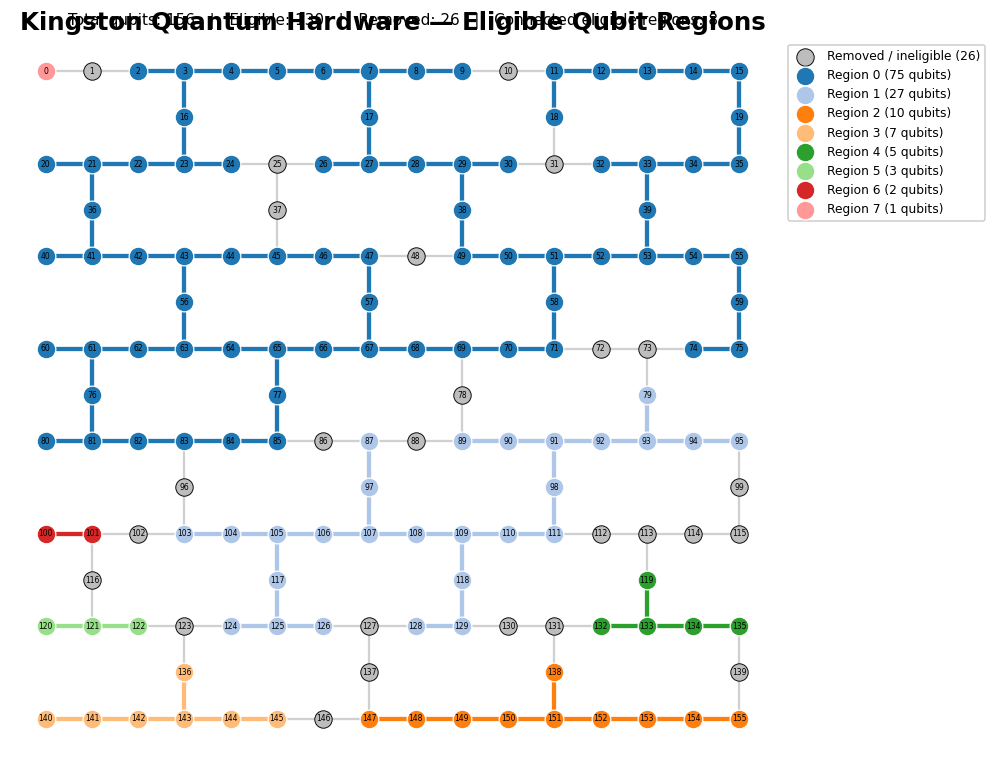

In [17]:
fig, ax = plot_eligible_regions(
    G=G,
    eligible_graph=eligible_graph,
    topology=topology,
    POS=POS,
    edges_declared=edges_declared
)

plt.show()

## Methodology

### Calculting the Region Score

Region Score = 0.45 * Node Quality + 0.40 * Edge Quality + 0.15 * density 

The values of coefficients are decided intutively without any explicit background in physics. We can call them as Objective Hyperparameters. 

In [18]:
def region_score(nodes):
    """Deterministic score for a connected candidate region."""
    nodes = tuple(sorted(nodes))
    H = eligible_graph.subgraph(nodes)
    if len(nodes) < 2 or not nx.is_connected(H):
        return -1e9

    internal_edges = [tuple(sorted(e)) for e in H.edges]
    if any(edge not in edge_quality for edge in internal_edges):
        return -1e9

    q_score = float(np.mean([node_quality[q] for q in nodes]))
    e_score = float(np.mean([edge_quality[e] for e in internal_edges]))
    density = H.number_of_edges() / (1.5 * len(nodes))  # max degree is 3 in this topology

    return 0.45 * q_score + 0.40 * e_score + 0.15 * density


### Performing the Beam Search for determining the optimal region for given scoring objection function

In [20]:
import heapq

def beam_search_region(k, beam_width=1200):
    """Find a high-scoring connected k-node region using deterministic beam search."""
    states = [(q,) for q in sorted(eligible_graph.nodes)]

    for size in range(2, k + 1):
        candidate_scores = {}

        for state in states:
            state_set = set(state)
            frontier = set()
            for q in state:
                frontier.update(v for v in eligible_graph.neighbors(q) if v not in state_set)

            for v in sorted(frontier):
                candidate = tuple(sorted(state + (v,)))
                if candidate not in candidate_scores:
                    candidate_scores[candidate] = region_score(candidate)

        states = heapq.nlargest(
            beam_width,
            candidate_scores.keys(),
            key=lambda s: (candidate_scores[s], tuple(-q for q in s)),
        )

        if size in (8, 16, 24, 32):
            print(f"size={size:2d}  best_score={region_score(states[0]):.6f}")

    return states[0]

# 4. Recommended 16-Qubit Region

In [21]:
recommended_16 = beam_search_region(16)
print("Recommended 16-qubit region:", recommended_16)

size= 8  best_score=0.667506
size=16  best_score=0.621329
Recommended 16-qubit region: (11, 12, 13, 14, 15, 19, 33, 34, 35, 39, 53, 54, 55, 59, 74, 75)


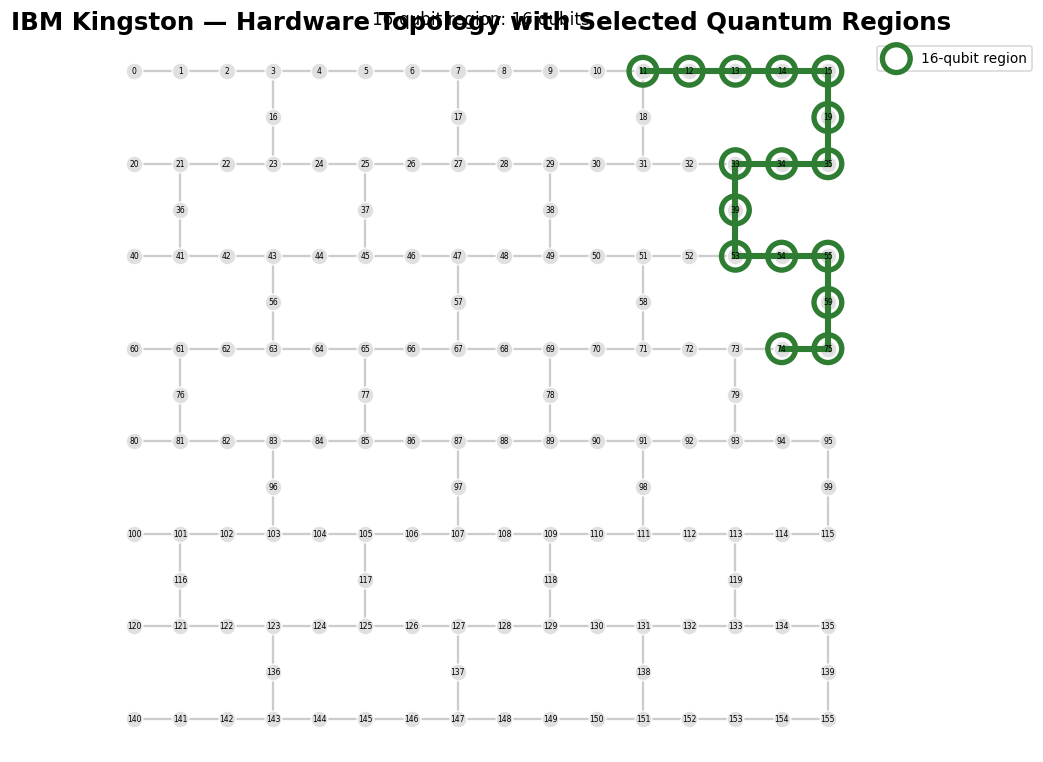

In [22]:
import matplotlib.pyplot as plt

R = sorted(recommended_16)
fig, ax = plt.subplots(figsize=(14, 7))
for u, v in edges_declared:

    ax.plot(
        [POS[u][0], POS[v][0]],
        [POS[u][1], POS[v][1]],
        color="#cccccc",
        linewidth=1.5,
        zorder=1
    )
all_qubits = list(range(topology["num_qubits"]))

ax.scatter(
    [POS[q][0] for q in all_qubits],
    [POS[q][1] for q in all_qubits],
    s=120,
    color="#e0e0e0",
    edgecolors="white",
    linewidths=0.8,
    zorder=2
)
ax.scatter(
    [POS[q][0] for q in R],
    [POS[q][1] for q in R],
    s=330,
    facecolors="none",
    edgecolors="#2e7d32",
    linewidths=3.5,
    zorder=5,
    label="16-qubit region"
)

R_set = set(R)

for u, v in edges_declared:
    if u in R_set and v in R_set:
        ax.plot(
            [POS[u][0], POS[v][0]],
            [POS[u][1], POS[v][1]],
            color="#2e7d32",
            linewidth=4,
            zorder=4
        )
for q in all_qubits:

    ax.annotate(
        str(q),
        POS[q],
        fontsize=5,
        ha="center",
        va="center",
        zorder=6
    )

ax.set_title(
    "IBM Kingston — Hardware Topology with Selected Quantum Regions",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    0.5,
    1.02,
    (
        f"16-qubit region: {len(R)} qubits"
    ),
    transform=ax.transAxes,
    ha="center",
    fontsize=11
)
ax.set_aspect("equal")
ax.axis("off")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    fontsize=9
)

plt.tight_layout()
plt.show()

In [23]:
def region_statistics(region, df, edge_cz, G):
    region = tuple(sorted(region))
    region_df = (
        df[df["Qubit"].isin(region)]
        .copy()
        .set_index("Qubit")
    )

    node_columns = [
        "T1 (us)",
        "T2 (us)",
        "Readout assignment error",
        "√x (sx) error",
    ]

    print("=" * 70)
    print(f"REGION STATISTICS")
    print(f"Number of qubits: {len(region)}")
    print(f"Qubits: {region}")
    print("=" * 70)

    print("\nQUBIT-LEVEL METRICS")
    print("-" * 70)

    # Mean / median / std / min / max
    node_stats = pd.DataFrame({
        "Mean": region_df[node_columns].mean(),
        "Median": region_df[node_columns].median(),
        "Std": region_df[node_columns].std(),
        "Min": region_df[node_columns].min(),
        "Max": region_df[node_columns].max(),
    })

    print(node_stats.round(6))
    region_set = set(region)

    internal_edges = [
        tuple(sorted((u, v)))
        for u, v in G.edges()
        if u in region_set and v in region_set
    ]

    # Get CZ errors only for available calibrated edges
    cz_values = [
        edge_cz[e]
        for e in internal_edges
        if e in edge_cz and pd.notna(edge_cz[e])
    ]

    print("\nEDGE-LEVEL METRICS")
    print("-" * 70)

    print(f"Internal edges: {len(internal_edges)}")
    print(f"Edges with CZ calibration: {len(cz_values)}")

    if cz_values:

        edge_stats = pd.Series(cz_values, name="CZ error").agg(
            ["mean", "median", "std", "min", "max"]
        )

        print(
            pd.DataFrame({
                "Mean": [edge_stats["mean"]],
                "Median": [edge_stats["median"]],
                "Std": [edge_stats["std"]],
                "Min": [edge_stats["min"]],
                "Max": [edge_stats["max"]],
            }).round(6).to_string(index=False)
        )

    else:
        print("No calibrated CZ edges found.")
    return {
        "region": region,
        "node_stats": node_stats,
        "internal_edges": internal_edges,
        "cz_values": cz_values,
    }

In [24]:
stats_16 = region_statistics(
    recommended_16,
    df=df,
    edge_cz=edge_cz,
    G=G
)

REGION STATISTICS
Number of qubits: 16
Qubits: (11, 12, 13, 14, 15, 19, 33, 34, 35, 39, 53, 54, 55, 59, 74, 75)

QUBIT-LEVEL METRICS
----------------------------------------------------------------------
                                Mean      Median         Std         Min         Max
T1 (us)                   306.884777  302.161726   64.620893  161.966244  420.592924
T2 (us)                   249.924905  247.913467  133.107908   50.952240  488.482105
Readout assignment error    0.018921    0.015808    0.011467    0.005249    0.040405
√x (sx) error               0.000195    0.000154    0.000108    0.000087    0.000515

EDGE-LEVEL METRICS
----------------------------------------------------------------------
Internal edges: 15
Edges with CZ calibration: 15
    Mean   Median      Std      Min     Max
0.001695 0.001397 0.000821 0.000903 0.00347


# 5. Recommended 32-Qubit Region

In [25]:
recommended_32 = beam_search_region(32)

print("Recommended 32-qubit region:", recommended_32)
assert set(recommended_16).issubset(set(recommended_32))

size= 8  best_score=0.667506
size=16  best_score=0.621329
size=24  best_score=0.595352
size=32  best_score=0.593466
Recommended 32-qubit region: (11, 12, 13, 14, 15, 19, 33, 34, 35, 39, 47, 50, 51, 52, 53, 54, 55, 57, 58, 59, 63, 64, 65, 66, 67, 68, 69, 70, 71, 74, 75, 77)


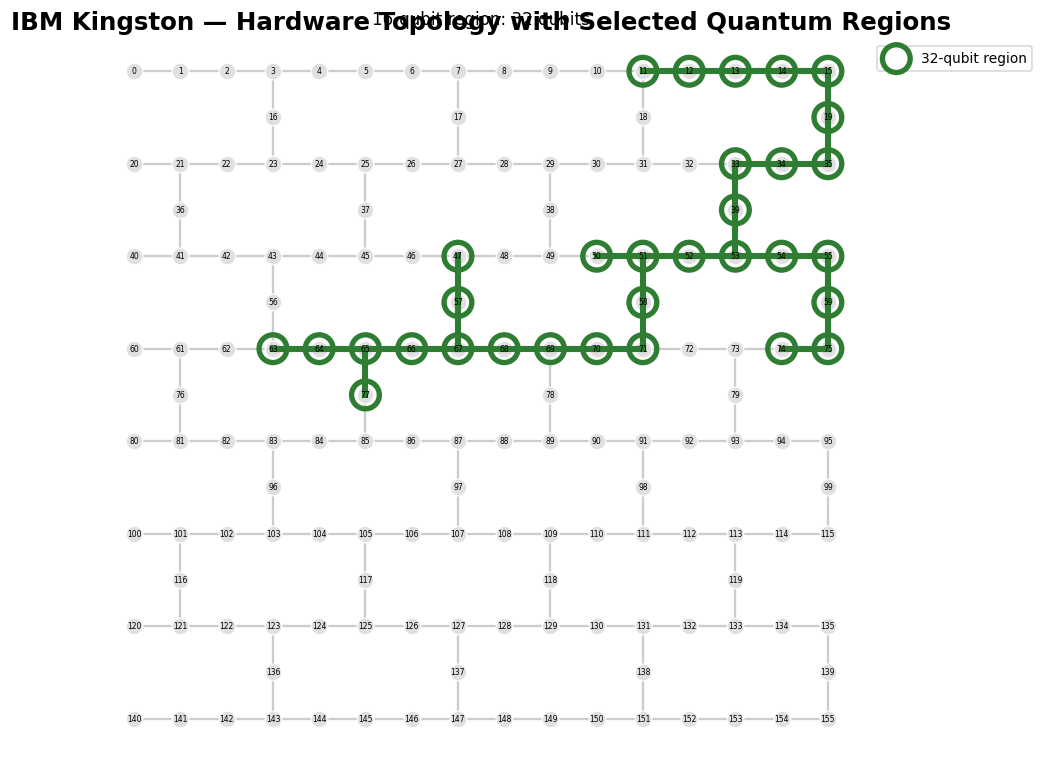

In [26]:
import matplotlib.pyplot as plt
import networkx as nx

R = sorted(recommended_32)
fig, ax = plt.subplots(figsize=(14, 7))
for u, v in edges_declared:

    ax.plot(
        [POS[u][0], POS[v][0]],
        [POS[u][1], POS[v][1]],
        color="#cccccc",
        linewidth=1.5,
        zorder=1
    )
all_qubits = list(range(topology["num_qubits"]))

ax.scatter(
    [POS[q][0] for q in all_qubits],
    [POS[q][1] for q in all_qubits],
    s=120,
    color="#e0e0e0",
    edgecolors="white",
    linewidths=0.8,
    zorder=2
)
ax.scatter(
    [POS[q][0] for q in R],
    [POS[q][1] for q in R],
    s=330,
    facecolors="none",
    edgecolors="#2e7d32",
    linewidths=3.5,
    zorder=5,
    label="32-qubit region"
)

R_set = set(R)

for u, v in edges_declared:
    if u in R_set and v in R_set:
        ax.plot(
            [POS[u][0], POS[v][0]],
            [POS[u][1], POS[v][1]],
            color="#2e7d32",
            linewidth=4,
            zorder=4
        )
for q in all_qubits:

    ax.annotate(
        str(q),
        POS[q],
        fontsize=5,
        ha="center",
        va="center",
        zorder=6
    )

ax.set_title(
    "IBM Kingston — Hardware Topology with Selected Quantum Regions",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    0.5,
    1.02,
    (
        f"16-qubit region: {len(R)} qubits"
    ),
    transform=ax.transAxes,
    ha="center",
    fontsize=11
)
ax.set_aspect("equal")
ax.axis("off")
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    fontsize=9
)
plt.tight_layout()
plt.show()

In [27]:
stats_32 = region_statistics(
    recommended_32,
    df=df,
    edge_cz=edge_cz,
    G=G
)

REGION STATISTICS
Number of qubits: 32
Qubits: (11, 12, 13, 14, 15, 19, 33, 34, 35, 39, 47, 50, 51, 52, 53, 54, 55, 57, 58, 59, 63, 64, 65, 66, 67, 68, 69, 70, 71, 74, 75, 77)

QUBIT-LEVEL METRICS
----------------------------------------------------------------------
                                Mean      Median         Std         Min         Max
T1 (us)                   295.871712  297.267923   68.454045  114.659257  420.592924
T2 (us)                   232.434247  238.377441  119.531161   50.952240  488.482105
Readout assignment error    0.016098    0.011719    0.011978    0.004517    0.047363
√x (sx) error               0.000229    0.000216    0.000099    0.000087    0.000515

EDGE-LEVEL METRICS
----------------------------------------------------------------------
Internal edges: 31
Edges with CZ calibration: 31
    Mean   Median      Std      Min     Max
0.001737 0.001573 0.000633 0.000903 0.00347


# 6. Recommendation Notes

### Recommendation Rationale

These recommendations are snapshot specific. 
The main rationale is to balance three things - 
1. High T1 and T2 time 
2. Low Readout Error and Single Qubit gate errors and CZ errors

### Additional Information That Would Improve Confidence

1. Additional information about the circuit would improve or even change the selection of the best region.  
2. Presence of more than one calibration snapshot would improve the confidence in the region.